## Process observed visibility
- time binning
- Rescale error

In [4]:
import os, sys
import numpy as np
from astropy.constants import c
from astropy import units as u
from collections import defaultdict
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cmcrameri import cm

from astropy.io import fits
from astropy.wcs import WCS

from casatasks import listobs, mstransform, statwt, simobserve, tclean, exportfits, uvsub
from casatools import ms, table

from glint.beam import cleanbeam_from_header
import glint.lensing as ls
from glint.context import ImageContext
from glint.forward import forward_model_3D_image
from glint.plotstyle import set_my_plot_style
from params_kinematics import param_names, param_table

%matplotlib inline

In [5]:
set_my_plot_style()

In [6]:
original_data_dir = "../../../G09/data/ALMA/Band6/combined/MS"
output_data_dir = "./data/MS"

# Tsujita
inms = os.path.join(original_data_dir, "Band6.tsujita.ms.contsub")
# Tadaki
# inms = os.path.join(original_data_dir, "Band6.tadaki.ms.contsub")
# Riechers
# inms = os.path.join(original_data_dir, "Band6.riechers.ms.contsub")
# _ = listobs(vis=inms, listfile=f"{inms}.listobs", overwrite=True)  # to check the spw info
!cat "{inms}.listobs"

           MeasurementSet Name:  /lwk/atsujita/G09/data/ALMA/Band6/combined/MS/Band6.tsujita.ms.contsub      MS Version 2
   Observer: riechers     Project: uid://A001/X1470/X98  
Observation: ALMA

  Telescope Observation Date    Observer       Project        
  ALMA      [                   5.0832e+09, 5.0832e+09]riechers       uid://A001/X1470/X98
  ALMA      [                   5.12783e+09, 5.12784e+09]riechers       uid://A001/X13ba/X1e3
  ALMA      [                   5.12861e+09, 5.12861e+09]riechers       uid://A001/X13ba/X1e3
  ALMA      [                   5.15014e+09, 5.15014e+09]tadakiken      uid://A001/X1526/X1326
  ALMA      [                   5.16196e+09, 5.16196e+09]tsujita        uid://A001/X1525/X1097
Data records: 463540       Total elapsed time = 3508.7 seconds
   Observed from   14-Jun-2022/21:41:05.0   to   14-Jun-2022/22:39:33.7 (UTC)

   ObservationID = 4         ArrayID = 0
  Date        Timerange (UTC)          Scan  FldId FieldName             nRows     Spw

## mstransform to timebin and regrid frequency

In [7]:
def check_ms(ms):
    # CORRECTED_DATA の有無を確認
    tb = table()
    tb.open(ms)
    cols = tb.colnames()
    tb.close()
    print("Has CORRECTED_DATA:", "CORRECTED_DATA" in cols)

In [8]:
# 時間平均とチャンネル平均（<100k visibilitiesが目安）
# 全チャンネルがflagされている場合のみ、出力もflagされる。そうでない場合は、flagされてないチャネルのみで平均され、flagは立たない。
# まだline free channelを使うので、全チャンネル出力する (nchan=-1の時startは無視される)
# chanaverageとregridでwidth指定する場合を比べると、どちらもvisibilityの計算は同じくらいになる。が、後者の場合エラーは更新されない。前者の場合、√channel数だけエラーが減る。
# preaverageという素晴らしい機能があるので、これで平均&regridできる。
# --> と思ったらバグで使えなかった... MSTransformManager::checkAndPreaverageChannelsIfNeeded	mstransform with regridms does not regrid properly for channel widths > or = 2 x the native channel width, when using channel pre-averaging. Please use clean or tclean for larger regridding. 
# --> 仕方ないので、先にchanaverageしてからregridすることにする。

REST_FREQ_CII = 1900.5369 * u.GHz
z = 6.024
OBS_FREQ_CII = REST_FREQ_CII / (1 + z)

# MSから周波数を読み出して、速度に変換する。

def get_vel_axis(ms, spw):
    tb = table()
    tb.open(ms+'/SPECTRAL_WINDOW')
    t1 = tb.selectrows([int(s) for s in spw.split(',')])
    freqs = t1.getcol("CHAN_FREQ")  # this column is the center freq of each channel===spw
    t1.close()
    tb.close()
    
    rest_freq = OBS_FREQ_CII.to(u.Hz).value
    vel_axis = (rest_freq - freqs) / rest_freq * c.to(u.km/u.s).value
    print(vel_axis)
    return vel_axis

spw = '0'
get_vel_axis(inms, spw)

# Tsujita
tempms = os.path.join(output_data_dir, f"Band6.tsujita.ms.contsub.tbin.chbin.temp")
outms = os.path.join(output_data_dir, f"Band6.tsujita.ms.contsub.tbin.chbin")
check_ms(inms)
# Tadaki
# outms = os.path.join(output_data_dir, f"Band6.tadaki.ms.contsub.tbin.chbin")
# Riechers
# outms = os.path.join(output_data_dir, f"Band6.riechers.ms.contsub.tbin.chbin")

os.system(f"rm -rf {outms}*")  # overwrite
os.system(f"rm -rf {tempms}*")  # overwrite
mstransform(vis=inms, outputvis=tempms, 
            field='G09-83808', spw=spw,
            datacolumn='data', 
            timeaverage=True, timebin='9999s', maxuvwdistance=12.0, timespan='scan', 
            chanaverage=True, chanbin=11, restfreq=f'{OBS_FREQ_CII.to(u.GHz).value}GHz', outframe='BARY',
            keepflags=True) 
get_vel_axis(tempms, spw)
mstransform(vis=tempms, outputvis=outms, 
            field='G09-83808', spw=spw,
            datacolumn='data', 
            regridms=True, preaverage=True, mode='velocity', width='50km/s', start='-675km/s', nchan=41, interpolation='linear', restfreq=f'{OBS_FREQ_CII.to(u.GHz).value}GHz', outframe='BARY',
            keepflags=True) 
# os.system(f"rm -rf {tempms}")  # remove the intermediate file
_ = listobs(vis=outms, listfile=f"{outms}.listobs", overwrite=True)  # to check the spw info
!cat "{outms}.listobs"

[[1344.17193402]
 [1339.84358373]
 [1335.51523344]
 [1331.18688314]
 [1326.85853285]
 [1322.53018256]
 [1318.20183227]
 [1313.87348198]
 [1309.54513169]
 [1305.2167814 ]
 [1300.88843111]
 [1296.56008081]
 [1292.23173052]
 [1287.90338023]
 [1283.57502994]
 [1279.24667965]
 [1274.91832936]
 [1270.58997907]
 [1266.26162878]
 [1261.93327849]
 [1257.60492819]
 [1253.2765779 ]
 [1248.94822761]
 [1244.61987732]
 [1240.29152703]
 [1235.96317674]
 [1231.63482645]
 [1227.30647616]
 [1222.97812587]
 [1218.64977557]
 [1214.32142528]
 [1209.99307499]
 [1205.6647247 ]
 [1201.33637441]
 [1197.00802412]
 [1192.67967383]
 [1188.35132354]
 [1184.02297325]
 [1179.69462295]
 [1175.36627266]
 [1171.03792237]
 [1166.70957208]
 [1162.38122179]
 [1158.0528715 ]
 [1153.72452121]
 [1149.39617092]
 [1145.06782062]
 [1140.73947033]
 [1136.41112004]
 [1132.08276975]
 [1127.75441946]
 [1123.42606917]
 [1119.09771888]
 [1114.76936859]
 [1110.4410183 ]
 [1106.112668  ]
 [1101.78431771]
 [1097.45596742]
 [1093.1276171

2026-04-15 14:35:50	WARN	MSTransformManager::parseTimeAvgParams	Operating with ALMA data, automatically adding state to timespan 
2026-04-15 14:35:50	WARN	MSTransformManager::parseTimeAvgParams+	In order to remove sub-scan boundaries which limit time average to 30s 
2026-04-15 14:35:50	WARN	MSTransformManager::checkCorrelatorPreaveraging	The data has already been preaveraged by the correlator but further smoothing or averaging has been requested. Preaveraged SPWs are: 0 
2026-04-15 14:36:02	WARN	MSTransformManager::dropNonUniformWidthChannels	Not enough input channels to populate output channel n# 43 from SPW 0.
2026-04-15 14:36:02	WARN	MSTransformManager::dropNonUniformWidthChannels+	The channel will be dropped in order to have an uniform grid.


[[1322.53018256]
 [1274.91832936]
 [1227.30647616]
 [1179.69462295]
 [1132.08276975]
 [1084.47091655]
 [1036.85906335]
 [ 989.24721014]
 [ 941.63535694]
 [ 894.02350374]
 [ 846.41165054]
 [ 798.79979733]
 [ 751.18794413]
 [ 703.57609093]
 [ 655.96423772]
 [ 608.35238452]
 [ 560.74053132]
 [ 513.12867812]
 [ 465.51682491]
 [ 417.90497171]
 [ 370.29311851]
 [ 322.68126531]
 [ 275.0694121 ]
 [ 227.4575589 ]
 [ 179.8457057 ]
 [ 132.2338525 ]
 [  84.62199929]
 [  37.01014609]
 [ -10.60170711]
 [ -58.21356032]
 [-105.82541352]
 [-153.43726672]
 [-201.04911992]
 [-248.66097313]
 [-296.27282633]
 [-343.88467953]
 [-391.49653273]
 [-439.10838594]
 [-486.72023914]
 [-534.33209234]
 [-581.94394554]
 [-629.55579875]
 [-677.16765195]]
           MeasurementSet Name:  /lwk/atsujita/HATLASJ0900/glint/examples/data/MS/Band6.tsujita.ms.contsub.tbin.chbin      MS Version 2
   Observer: riechers     Project: uid://A001/X1470/X98  
Observation: ALMA

  Telescope Observation Date    Observer       Project 

In [9]:
v_kms = get_vel_axis(outms, spw)
is_cont_ch = (np.abs(v_kms) >= 350.0)  # (nchan,)
print("line-free channels:", np.where(is_cont_ch)[0])

[[1325.]
 [1275.]
 [1225.]
 [1175.]
 [1125.]
 [1075.]
 [1025.]
 [ 975.]
 [ 925.]
 [ 875.]
 [ 825.]
 [ 775.]
 [ 725.]
 [ 675.]
 [ 625.]
 [ 575.]
 [ 525.]
 [ 475.]
 [ 425.]
 [ 375.]
 [ 325.]
 [ 275.]
 [ 225.]
 [ 175.]
 [ 125.]
 [  75.]
 [  25.]
 [ -25.]
 [ -75.]
 [-125.]
 [-175.]
 [-225.]
 [-275.]
 [-325.]
 [-375.]
 [-425.]
 [-475.]
 [-525.]
 [-575.]
 [-625.]
 [-675.]]
line-free channels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 34 35 36 37
 38 39 40]


In [10]:
# Tsujita
outms_backup = os.path.join(output_data_dir, f"Band6.tsujita.ms.contsub.tbin.chbin.backup")
# ch_cont = "0:0~38; 68~81" # 25km/s binの場合
ch_cont = "0:0~19; 34~40" # 50km/s binの場合
# ch_cont = "0:0~22; 39~47" # 50km/s binの場合, regridなし
# {'mean': 3.102301217047004, 'variance': 0.22556013369656308}  # ch_cont指定した場合
# {'mean': 3.3021248515983537, 'variance': 0.23616071080880977} # ch_cont指定しない場合

# Tadaki
# outms_regrid_backup = os.path.join(output_data_dir, "Band6.tadaki.ms.contsub.tbin.chbin.regrid.backup")
# ch_cont = "0:0~51; 81" # 25km/s binの場合
# ch_cont = "0:0~25" # 50km/s binの場合

# Riechers
# outms_regrid_backup = os.path.join(output_data_dir, "Band6.riechers.ms.contsub.tbin.chbin.regrid.backup")
# ch_cont = "0:0~30; 60~81, 1:0~30; 60~81"

# Copy and statwt
os.system(f"rm -rf {outms_backup}")
os.system(f"cp -r {outms} {outms_backup}")
# os.system(f"cp -r {outms_backup} {outms}")
statwt(
    vis=outms, 
    datacolumn="data", 
    combine="scan, corr", 
    preview=False, 
    excludechans=False, 
    fitspw=ch_cont,
    minsamp=2,
    timebin='300s',
    flagbackup=True
)

check_ms(outms)

....10....20....30....40....50....60....70....80....90....100%


Has CORRECTED_DATA: False


In [11]:
# {'mean': 4862.259587235145, 'variance': 18835792.873411506}

In [12]:
tb = table()
tb.open(outms)
w = tb.getcol("WEIGHT")   # shape: (ncorr, nrow) が多い
s = tb.getcol("SIGMA")
tb.close()

print("WEIGHT min/med/max:", np.nanmin(w), np.nanmedian(w), np.nanmax(w))
print("SIGMA  min/med/max:", np.nanmin(s), np.nanmedian(s), np.nanmax(s))

# WEIGHTからsigmaを再計算して比較
sig_from_w = 1.0/np.sqrt(w)
print("sigma(from WEIGHT) min/med/max:", np.nanmin(sig_from_w), np.nanmedian(sig_from_w), np.nanmax(sig_from_w))

WEIGHT min/med/max: 31.345556259155273 3760.9757080078125 inf
SIGMA  min/med/max: 0.0 0.016306085512042046 0.1786125749349594
sigma(from WEIGHT) min/med/max: 0.0 0.016306086356291397 0.17861256585993743


In [13]:
#########################
# {'mean': 45.186852242859324, 'variance': 4.708463560305805}  # chanbin=spw, tbin=300s
#########################

# statwtはsigmaを更新してくれてないので注意！


### 軽くテスト

Shape of CORRECTED_DATA: (2, 41, 4658), WEIGHT: (2, 4658), FLAG: (2, 41, 4658)
z mean/std: -0.0021972899917184255 1.052370465002012
frac(|z|>3): 0.008167823810607785
frac(|z|>5): 0.0006999772365126338


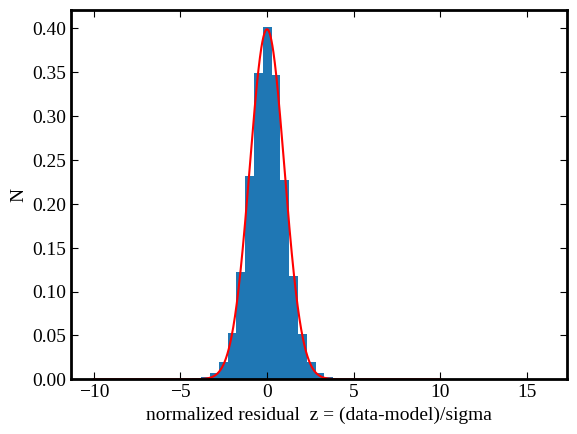

In [12]:
# まずσが正規分布になっているか確認

tb = table()
tb.open(outms)
cols = tb.colnames()
d = tb.getcol("DATA")           # shape (ncorr, nchan, nrow)
# r = tb.getcol("CORRECTED_DATA") # uvsub後の残差はCORRECTED_DATAに入っている
r= d
w = tb.getcol("WEIGHT")
f = tb.getcol("FLAG")
uvw = tb.getcol("UVW")      # shape (3, nrow) [m]
tb.close()

tb.open(outms + "/SPECTRAL_WINDOW")
chan_freq = tb.getcol("CHAN_FREQ")[:,0]  # Hz
tb.close()

s = 1.0/np.sqrt(w)
print(f"Shape of CORRECTED_DATA: {r.shape}, WEIGHT: {w.shape}, FLAG: {f.shape}")

# broadcast
s = s[:, None, :]
s = np.broadcast_to(s, r.shape)

# フラグを除外
good = ~f
z_re = np.real(r)[good] / s[good]
z_im = np.imag(r)[good] / s[good]

z = np.concatenate([z_re, z_im])

print("z mean/std:", np.mean(z), np.std(z))
print("frac(|z|>3):", np.mean(np.abs(z) > 3))
print("frac(|z|>5):", np.mean(np.abs(z) > 5))

plt.figure()
plt.hist(z, bins=50, density=True)
plt.xlabel("normalized residual  z = (data-model)/sigma")
plt.ylabel("N")

# ガウシアン分布も重ねてみる
from scipy.stats import norm
x = np.linspace(-10, 10, 1000)
pdf = norm.pdf(x, loc=0, scale=1)
plt.plot(x, pdf, color='red', label='Gaussian PDF')

plt.show()

In [13]:
tb.open(outms + "/SPECTRAL_WINDOW")
chan_freq = tb.getcol("CHAN_FREQ")  # Hz
tb.close()

chan_freq.shape

(41, 1)

/home/tsujtaak/miniconda3/envs/casa/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/tsujtaak/miniconda3/envs/casa/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/tsujtaak/miniconda3/envs/casa/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/tsujtaak/miniconda3/envs/casa/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tsujtaak/miniconda3/envs/casa/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


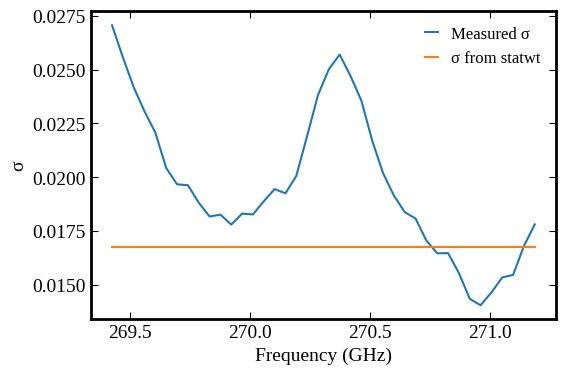

In [14]:
# チャンネルごとのノイズ・外れ値を確認

# ---- チャネル毎ノイズ比較 ----
s_data = []
s_statwt = []

for ch in range(r.shape[1]):
    good = ~f[:,ch,:]
    rr = r[:,ch,:][good]
    ss = s[:,ch,:][good]

    s_data.append(np.std(np.real(rr)))
    s_statwt.append(np.median(ss))

s_data = np.array(s_data)
s_statwt = np.array(s_statwt)

# ---- プロット ----
plt.figure(figsize=(6,4))
plt.plot(chan_freq/1e9, s_data, label="Measured σ")
plt.plot(chan_freq/1e9, s_statwt, label="σ from statwt")
plt.xlabel("Frequency (GHz)")
plt.ylabel("σ")
plt.legend()
plt.show()

uvdist [m] min/med/max: 0.0 353.35334118403927 1288.9241125156423
z_row mean/std: -0.00459659540883436 0.24556698874492808


/tmp/ipykernel_1410623/1055096559.py:7: RuntimeWarning: Mean of empty slice
  r_re_row = np.nanmean(np.where(f, np.nan, np.real(r)), axis=1)
/tmp/ipykernel_1410623/1055096559.py:8: RuntimeWarning: All-NaN slice encountered
  s_row    = np.nanmedian(np.where(f, np.nan, s), axis=1)  # chan方向はmedianが安全


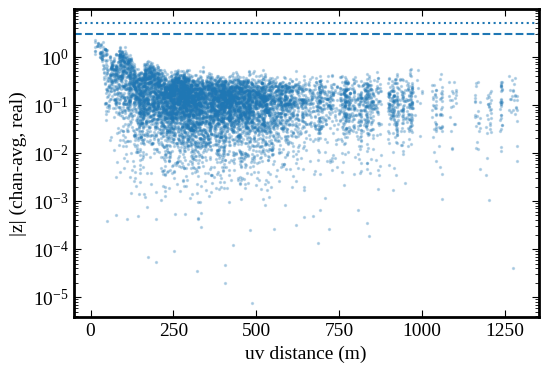

In [15]:
uvdist = np.sqrt(uvw[0]**2 + uvw[1]**2)  # [m], shape (nrow,)
print("uvdist [m] min/med/max:", np.min(uvdist), np.median(uvdist), np.max(uvdist))

ncorr, nchan, nrow = r.shape

# フラグをNaN化してchan平均 → (ncorr, nrow)
r_re_row = np.nanmean(np.where(f, np.nan, np.real(r)), axis=1)
s_row    = np.nanmedian(np.where(f, np.nan, s), axis=1)  # chan方向はmedianが安全

# corrもまとめて 1本に
r_re_row_1d = r_re_row.ravel()          # (ncorr*nrow,)
s_row_1d    = s_row.ravel()             # (ncorr*nrow,)
uv_rep      = np.tile(uvdist, ncorr)    # (ncorr*nrow,)

m = np.isfinite(r_re_row_1d) & np.isfinite(s_row_1d)
r_re_row_1d = r_re_row_1d[m]
s_row_1d    = s_row_1d[m]
uv_rep      = uv_rep[m]

# “rowごとの正規化残差”
z_row = r_re_row_1d / s_row_1d
print("z_row mean/std:", np.mean(z_row), np.std(z_row))

plt.figure(figsize=(6,4))
plt.scatter(uv_rep, np.abs(z_row), s=2, alpha=0.25)
plt.axhline(3, ls="--")
plt.axhline(5, ls=":")
plt.yscale("log")
plt.xlabel("uv distance (m)")
plt.ylabel("|z| (chan-avg, real)")
plt.show()

## signal-to-noise map

SNR row (per corr) median: [1.27239543 1.25781014]


/tmp/ipykernel_1410623/3837773535.py:12: RuntimeWarning: Mean of empty slice
  amp_row   = np.nanmean(Vabs, axis=1)        # (ncorr, nrow)
/tmp/ipykernel_1410623/3837773535.py:13: RuntimeWarning: All-NaN slice encountered
  sig_row   = np.nanmedian(sig, axis=1)       # (ncorr, nrow)  medianが頑丈


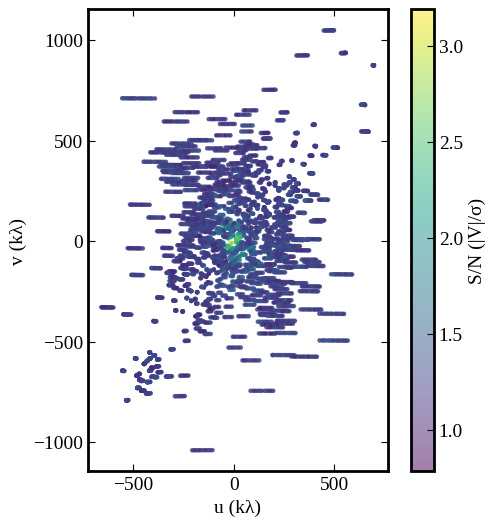

In [16]:
from astropy.constants import c

# vis0 = outputvis   # "./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms.tbin"
vis = outms


# フラグをNaN化してチャネル平均（各rowに1値）
Vabs = np.abs(d)
Vabs = np.where(f, np.nan, Vabs)
sig  = np.where(f, np.nan, s)

amp_row   = np.nanmean(Vabs, axis=1)        # (ncorr, nrow)
sig_row   = np.nanmedian(sig, axis=1)       # (ncorr, nrow)  medianが頑丈
snr_row   = amp_row / sig_row               # (ncorr, nrow)

print("SNR row (per corr) median:", np.nanmedian(snr_row, axis=1))

nu = np.median(chan_freq)  # Hz
lam = (c.value) / nu       # m

u_kl = uvw[0] / lam / 1e3
v_kl = uvw[1] / lam / 1e3

snr_1d = snr_row.ravel()                 # (ncorr*nrow,)
u_1d   = np.tile(u_kl, snr_row.shape[0])
v_1d   = np.tile(v_kl, snr_row.shape[0])

m = np.isfinite(snr_1d)
snr_1d = snr_1d[m]
u_1d   = u_1d[m]
v_1d   = v_1d[m]

plt.figure(figsize=(6,6))
sc = plt.scatter(u_1d, v_1d, c=snr_1d, s=5, alpha=0.5)
plt.xlabel("u (kλ)")
plt.ylabel("v (kλ)")
plt.gca().set_aspect("equal", "box")
plt.colorbar(sc, label="S/N (|V|/σ)")
plt.show()

In [17]:
good = ~f
rr = d[good]
ss = s[good]

chi2_complex = np.sum( (np.real(rr)/ss)**2 + (np.imag(rr)/ss)**2 )
Ndof = 2 * rr.size   # ReとImで2自由度（厳密にはflagで変わるがOK）

print("chi2_complex:", chi2_complex)
print("chi2/dof:", chi2_complex / Ndof)

chi2_complex: 778431.4632445342
chi2/dof: 1.1074884236918594


In [17]:
good = ~f
rr = r[good]
ss = s[good]

chi2_complex = np.sum( (np.real(rr)/ss)**2 + (np.imag(rr)/ss)**2 )
Ndof = 2 * rr.size   # ReとImで2自由度（厳密にはflagで変わるがOK）

print("chi2_complex:", chi2_complex)
print("chi2/dof:", chi2_complex / Ndof)

print("rr real std:", np.std(np.real(rr)))
print("rr imag std:", np.std(np.imag(rr)))
print("ss median:", np.median(ss))
print("ss p16/p50/p84:", np.percentile(ss, [16,50,84]))
print("min/max ss:", np.min(ss), np.max(ss))

chi2_complex: 778431.4632445342
chi2/dof: 1.1074884236918594
rr real std: 0.019923844142028496
rr imag std: 0.01978797196317511
ss median: 0.016783462111515827
ss p16/p50/p84: [0.01149065 0.01678346 0.02341761]
min/max ss: 0.005397600434259825 0.17861256585993743


## テスト完了したので、あとは保存する

汎用的にしておく

In [18]:
## uv dataをbinにまとめる
    
def getdata(ms):
    """
    注意：配列が同じshapeでないと全部取れない。channel数がspwによって違う場合は正しくない。
    そういう場合は getvarcol を使うこと。ここではどうせ全部平均するので問題ないが。
    uは東向き正になっている模様：https://casa.nrao.edu/Memos/CoordConvention.pdf 
    """
    tb = table()
    tb.open(ms)
    obsid      = np.squeeze(tb.getcol("OBSERVATION_ID")) # EB
    uvw        = np.squeeze(tb.getcol("UVW")) # uは東向き正になっているので注意、あとでu*l計算するときに符号反転させる
    ant1       = np.squeeze(tb.getcol("ANTENNA1"))
    ant2       = np.squeeze(tb.getcol("ANTENNA2"))
    data_pol   = np.squeeze(tb.getcol("DATA"))
    # corrected_pol = np.squeeze(tb.getcol("CORRECTED_DATA"))
    sigma_pol  = np.squeeze(tb.getcol("SIGMA"))
    weight_pol = np.squeeze(tb.getcol("WEIGHT"))
    data_id    = np.squeeze(tb.getcol("DATA_DESC_ID")) # SPW
    time       = np.squeeze(tb.getcol("TIME"))
    scan       = np.squeeze(tb.getcol("SCAN_NUMBER"))
    flag       = np.squeeze(tb.getcol("FLAG"))
    tb.close()

    # phase center
    tb.open(ms + "/FIELD")
    phase_dir = np.squeeze(tb.getcol("PHASE_DIR"))
    tb.close()
    phase_dir = np.rad2deg(phase_dir)  # [rad] -> [deg]
    
    # print shapes
    print(f"Shape of obsid: {obsid.shape}")
    print(f"Shape of uvw: {uvw.shape}")
    print(f"Shape of ant1: {ant1.shape}")
    print(f"Shape of ant2: {ant2.shape}")
    print(f"Shape of data: {data_pol.shape}")
    print(f"Shape of sigma: {sigma_pol.shape}")
    print(f"Shape of weight: {weight_pol.shape}")
    print(f"Shape of data_id: {data_id.shape}")
    print(f"Shape of time: {time.shape}")
    print(f"Shape of scan: {scan.shape}")
    print(f"Shape of flag: {flag.shape}")
    print(f"phase center (deg): {phase_dir}")

    return obsid, uvw, ant1, ant2, data_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir
    # return obsid, uvw, ant1, ant2, data_pol, corrected_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir

In [19]:
# uvsubは終わっていて、CORRECTED_DATAに残差が入っている
# かつstatwtでWEIGHTが更新されていることを想定

vis0 = outms   # "./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms.tbin"
obsid, uvw, ant1, ant2, data_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir = getdata(vis0)
# obsid, uvw, ant1, ant2, data_pol, corrected_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir = getdata(vis0)

print(f"Number of flagged data points: {np.sum(flag)} / {flag.size}")

Shape of obsid: (4658,)
Shape of uvw: (3, 4658)
Shape of ant1: (4658,)
Shape of ant2: (4658,)
Shape of data: (2, 41, 4658)
Shape of sigma: (2, 4658)
Shape of weight: (2, 4658)
Shape of data_id: (4658,)
Shape of time: (4658,)
Shape of scan: (4658,)
Shape of flag: (2, 41, 4658)
phase center (deg): [135.19097083   0.68977778]
Number of flagged data points: 30516 / 381956


In [20]:
# 周波数
# Get the frequencies assoc. with each spw, since uvw coordinates are in m, not wavelengths
spw = "0"
tb = table()
tb.open(vis0+'/SPECTRAL_WINDOW')
t1 = tb.selectrows([int(s) for s in spw.split(',')])
freqs = np.squeeze(t1.getcol('CHAN_FREQ')) # 複数のspwがある場合、揃えた上で最初のspwの周波数を使う
t1.close(); tb.close()

print("Frequencies for each SPW (Hz):", freqs)


# Get the primary beam size
diam = 12.0  # ALMA antenna diameter in m
PBfwhm = (1.13 * (c / np.mean(freqs*u.Hz)) / (diam*u.m) * (3600*180/np.pi)).to("")

print(f"Primary beam FWHM (arcsec): {PBfwhm:.3f}")


v_kms = -( (freqs - OBS_FREQ_CII.to(u.Hz).value) / OBS_FREQ_CII.to(u.Hz).value * c.to(u.km/u.s).value )  # (nchan,)
print(v_kms)

# # 
# is_cont_ch = (np.abs(v_kms) >= 350.0)  # (nchan,)
# print("line-free channels:", np.where(is_cont_ch)[0])
is_line_ch = (np.abs(v_kms) < 350.0)  # (nchan,)
print("line channels:", np.where(is_line_ch)[0])

Frequencies for each SPW (Hz): [2.69381699e+11 2.69426826e+11 2.69471954e+11 2.69517081e+11
 2.69562209e+11 2.69607336e+11 2.69652463e+11 2.69697591e+11
 2.69742718e+11 2.69787846e+11 2.69832973e+11 2.69878101e+11
 2.69923228e+11 2.69968356e+11 2.70013483e+11 2.70058611e+11
 2.70103738e+11 2.70148866e+11 2.70193993e+11 2.70239121e+11
 2.70284248e+11 2.70329376e+11 2.70374503e+11 2.70419631e+11
 2.70464758e+11 2.70509886e+11 2.70555013e+11 2.70600141e+11
 2.70645268e+11 2.70690396e+11 2.70735523e+11 2.70780651e+11
 2.70825778e+11 2.70870906e+11 2.70916033e+11 2.70961160e+11
 2.71006288e+11 2.71051415e+11 2.71096543e+11 2.71141670e+11
 2.71186798e+11]
Primary beam FWHM (arcsec): 21.544
[1325. 1275. 1225. 1175. 1125. 1075. 1025.  975.  925.  875.  825.  775.
  725.  675.  625.  575.  525.  475.  425.  375.  325.  275.  225.  175.
  125.   75.   25.  -25.  -75. -125. -175. -225. -275. -325. -375. -425.
 -475. -525. -575. -625. -675.]
line channels: [20 21 22 23 24 25 26 27 28 29 30 31 32 3

In [21]:
# # execution blocks
# uniq = np.unique(obsid)
# print("Unique OBSERVATION_IDs:", uniq)

# # 複数のObservationがある場合に、人工的にスケーリングを加えられるようにする
# noisefac = [1.0] * len(uniq)
# print("Noise scaling factors for each OBSERVATION_ID:", noisefac)

# if uniq.size > 1:
#     print("Multiple OBSERVATION_IDs found. Shift antenna numbers accordingly.")
#     for i, oid in enumerate(uniq):
#         m = (obsid == oid)
#         ant1[m] += i * 1000
#         ant2[m] += i * 1000
# else:
#     print("Single OBSERVATION_ID found. No need to shift antenna numbers.")
#     pass

In [22]:
# import astropy.units as u
# # Get the primary beam size
# diam = 12.0  # ALMA antenna diameter in m
# PBfwhm = (1.13 * (c / (freqs*u.Hz)) / (diam*u.m) * (3600*180/np.pi)).to("")
# # PBfwhm = (1.13 * (c / np.mean(freqs*u.Hz)) / (diam*u.m) * (3600*180/np.pi)).to("")

# print(f"Primary beam FWHM (arcsec): {PBfwhm}")

In [23]:
# --- pol平均（チャネルごと）: weightベースで一貫させる ---
# weight_pol==0 は 1e-99 にせず、そのまま0で扱い、分母=0は np.divide の where で弾く
# （一応）flagを重みに反映
w_all = np.where(flag, 0.0, np.broadcast_to(weight_pol[:, None, :].astype(float), data_pol.shape))  # (2, nchan, Nrow)

num = np.sum(w_all * data_pol, axis=0)     # (nchan, Nrow)
den = np.sum(w_all, axis=0)                # (nchan, Nrow)

data  = np.divide(num, den, out=np.zeros_like(num), where=(den > 0))
weight = den.copy()
sigma  = np.full_like(den, np.inf, dtype=float)
m_ok   = den > 0
sigma[m_ok] = 1.0 / np.sqrt(den[m_ok])

In [24]:
data.shape, sigma.shape, weight.shape, flag.shape, freqs.shape

((41, 4658), (41, 4658), (41, 4658), (2, 41, 4658), (41,))

In [25]:
wl_m = c.to(u.m/u.s).value / freqs  # wavelength in m (nchan, )
uvw_lam = uvw[:, None, :] / wl_m[None, :, None]  # (3, nchan, nrow)にそれぞれbroadcast
print("uvw (in meters) shape:", uvw.shape)
print("uvw (in wavelengths) shape:", uvw_lam.shape)

uvw (in meters) shape: (3, 4658)
uvw (in wavelengths) shape: (3, 41, 4658)


In [26]:
data[4]

array([ 0.04323665+0.01873754j,  0.004386  -0.00693812j,
        0.01212318-0.0012269j , ..., -0.04020131+0.00590291j,
        0.00628532-0.14131767j,  0.01268835-0.12542067j], shape=(4658,))

In [27]:
uvw_lam[:2]

array([[[-553795.41901787,  564755.23392984,  546499.62870499, ...,
          227475.28468693,   75586.06212698,  159214.71679342],
        [-553888.19218362,  564849.84311064,  546591.17966206, ...,
          227513.39190408,   75598.72448934,  159241.38883295],
        [-553980.96534936,  564944.45229144,  546682.73061914, ...,
          227551.49912123,   75611.3868517 ,  159268.06087249],
        ...,
        [-557320.79931623,  568350.38280019,  549978.56507379, ...,
          228923.35893865,   76067.23189672,  160228.25429574],
        [-557413.57248197,  568444.99198099,  550070.11603086, ...,
          228961.4661558 ,   76079.89425908,  160254.92633528],
        [-557506.34564772,  568539.60116179,  550161.66698794, ...,
          228999.57337295,   76092.55662144,  160281.59837481]],

       [[ 709030.99250716, -493008.24641304, -360411.83702188, ...,
          131362.92313559,  296022.35197127, -114494.6698832 ],
        [ 709149.7711166 , -493090.83636266, -360472.21409606

In [28]:
flag = flag[0]

In [29]:
sigma == 1/weight**0.5

/tmp/ipykernel_1618701/710509974.py:1: RuntimeWarning: divide by zero encountered in divide
  sigma == 1/weight**0.5


array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(41, 4658))

In [30]:
uvw.shape

(3, 4658)

In [31]:
# line channelだけに絞る
data = data[is_line_ch]
sigma = sigma[is_line_ch]
weight = weight[is_line_ch]
uvw_lam = uvw_lam[:, is_line_ch, :]
freqs = freqs[is_line_ch]
v_kms = v_kms[is_line_ch]
flag = flag[is_line_ch]


In [32]:
# Save the processed uv data for later use
np.savez(
    os.path.join('./sim_imaging', "G09.processed_uv_CII.npz"),
    uvw=uvw,
    uvw_lam=uvw_lam,
    ant1=ant1,
    ant2=ant2,
    data=data,
    sigma=sigma,
    weight=weight,
    data_id=data_id,
    time=time,
    scan=scan,
    flag=flag,
    pb_fwhm=PBfwhm.value,
    phase_dir=phase_dir,  # [deg]
    freqs=freqs,          # [Hz]
    v_kms=v_kms,          # [km/s]
)

In [38]:
v_kms.shape

(14,)